# OCT Scan Disease Detector — APS360

A convolutional neural network, **trained from scratch**, that classifies retinal OCT scans into
**CNV / DME / Drusen / Normal**. It's benchmarked against a HOG + SVM baseline, audited with
Grad-CAM, and stress-tested on a second dataset (OCTDL) from a different scanner.

- **Report:** [`report/OCT_Scan_Disease_Detector_Report.pdf`](../report/OCT_Scan_Disease_Detector_Report.pdf)
- **Overview:** see the repository [`README.md`](../README.md)
- **Runtime:** Google Colab with a GPU. Set your own Drive paths in the config cell below.

## 1. Setup & data preparation

In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/APS360/APS360 Project"   # project folder on Google Drive
OCTDL_ROOT = "/content/drive/MyDrive/APS360/OCTDL Dataset"    # external OCTDL dataset folder

DATA_ZIP = f"{DRIVE_ROOT}/ZhangLabData.zip"     # zipped Kermany OCT dataset
CACHE    = f"{DRIVE_ROOT}/preloaded_uint8.pt"   # cached preprocessed tensors (built once)
WEIGHTS  = f"{DRIVE_ROOT}/cnn_full.pt"          # trained CNN weights

DATA_DIR = "/content/data"                      # local unzip target (fast to read from)
ROOT     = f"{DATA_DIR}/CellData/OCT"           # dataset root (contains train/ and test/)

classes      = ["CNV", "DME", "DRUSEN", "NORMAL"]
class_to_idx = {"CNV": 0, "DME": 1, "DRUSEN": 2, "NORMAL": 3}
idx_to_class = {i: c for c, i in class_to_idx.items()}

In [ ]:
# Mount Drive and unzip the Kermany OCT dataset into local Colab storage.
# Reading from local disk is much faster than from Drive during preprocessing.
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

shutil.copy(DATA_ZIP, "/content/data.zip")
shutil.unpack_archive("/content/data.zip", DATA_DIR)
print("done unzipping")

# Sanity check: print the folder tree (up to 2 levels deep) with file counts.
for dirpath, dirnames, filenames in os.walk(DATA_DIR):
    depth = dirpath[len(DATA_DIR):].count(os.sep)
    if depth <= 2:
        print(" " * depth + os.path.basename(dirpath) + os.sep + f" ({len(filenames)} files)")

Mounted at /content/drive
done unzipping
data/ (0 files)
 CellData/ (0 files)
  chest_xray/ (1 files)
  OCT/ (0 files)
  code/ (3 files)


In [ ]:
# Count images and unique patients per class.
# Each filename looks like  <class>-<patientID>-<scan>.jpeg,  so the patient ID
# is the second hyphen-separated field.
import os

for split in ["train", "test"]:
    print("=====", split, "=====")
    for c in classes:
        folder = os.path.join(ROOT, split, c)
        files = os.listdir(folder)
        patients = {name.split("-")[1] for name in files}
        print(c, "->", len(files), "images,", len(patients), "patients")

===== train =====
CNV -> 37205 images, 791 patients
DME -> 11348 images, 709 patients
DRUSEN -> 8616 images, 713 patients
NORMAL -> 51140 images, 3434 patients
===== test =====
CNV -> 250 images, 178 patients
DME -> 250 images, 167 patients
DRUSEN -> 250 images, 169 patients
NORMAL -> 250 images, 171 patients


In [ ]:
# Patient-level train/val split (~90/10).
# Splitting by PATIENT (not by image) keeps near-identical scans of the same eye
# out of both splits, mixing them would inflate validation accuracy.
import random

TRAIN_ROOT   = os.path.join(ROOT, "train")
VAL_FRACTION = 0.10
random.seed(42)

# Every patient ID that appears anywhere in the training pool.
train_patients = set()
for c in classes:
    for name in os.listdir(os.path.join(TRAIN_ROOT, c)):
        train_patients.add(name.split("-")[1])
train_patients = sorted(train_patients)

# Randomly hold out 10% of PATIENTS for validation.
n_val = int(len(train_patients) * VAL_FRACTION)
val_patients = set(random.sample(train_patients, n_val))

# Assign each image to train or val based on its patient's split.
split_files = {"train": {c: [] for c in classes}, "val": {c: [] for c in classes}}
for c in classes:
    for name in os.listdir(os.path.join(TRAIN_ROOT, c)):
        pid = name.split("-")[1]
        where = "val" if pid in val_patients else "train"
        split_files[where][c].append(name)

# Report the resulting class balance in each split.
for where in ["train", "val"]:
    total = sum(len(split_files[where][c]) for c in classes)
    print(f"\n{where}: {total} images")
    for c in classes:
        n = len(split_files[where][c])
        print(f"  {c:8}{n:>7} ({100*n/total:.1f}%)")


train: 98050 images
 CNV       33932 (34.6%)
 DME       10227 (10.4%)
 DRUSEN     7863 (8.0%)
 NORMAL    46028 (46.9%)

val: 10259 images
 CNV        3273 (31.9%)
 DME        1121 (10.9%)
 DRUSEN      753 (7.3%)
 NORMAL     5112 (49.8%)


In [ ]:
# Preprocessing applied to every scan before it is cached as a tensor:
# grayscale -> resize to 224x224 -> uint8 tensor.
import torch
from torchvision import transforms
from PIL import Image

preload_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.PILToTensor(),
])

In [ ]:
# Minimal Dataset that opens an image path and applies the transform.
from torch.utils.data import Dataset

class ItemsDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items          # list of (path, label)
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, label = self.items[i]
        img = Image.open(path)
        return self.transform(img), label

In [ ]:
# Build (path, label) lists for each split from the patient-level split above.
def make_items(split_name):
    items = []
    for c in classes:
        label = class_to_idx[c]
        folder = os.path.join(ROOT, "train", c)
        for fname in split_files[split_name][c]:
            items.append((os.path.join(folder, fname), label))
    return items

def make_test_items():
    # The supplied test set has its own folder and is left completely untouched.
    items = []
    for c in classes:
        label = class_to_idx[c]
        folder = os.path.join(ROOT, "test", c)
        for fname in os.listdir(folder):
            items.append((os.path.join(folder, fname), label))
    return items

train_items = make_items("train")
val_items   = make_items("val")
test_items  = make_test_items()
print(len(train_items), len(val_items), len(test_items))

98050 10259 1000


In [ ]:
# Decode every image once (in parallel) into one uint8 tensor per split.
# Storing as uint8 (1 byte/pixel) keeps the FULL training pool in RAM, so training
# never re-reads or re-decodes images from disk between epochs.
from torch.utils.data import DataLoader

def preload(items, transform):
    ds = ItemsDataset(items, transform)
    loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=2)

    N = len(ds)
    X = torch.empty((N, 1, 224, 224), dtype=torch.uint8)
    Y = torch.empty((N,), dtype=torch.long)

    i = 0
    for xb, yb in loader:
        b = xb.size(0)
        X[i:i+b] = xb
        Y[i:i+b] = yb
        i += b
    return X, Y

train_x, train_y = preload(train_items, preload_transform)
val_x,   val_y   = preload(val_items,   preload_transform)
test_x,  test_y  = preload(test_items,  preload_transform)

for name, t in [("train", train_x), ("val", val_x), ("test", test_x)]:
    gb = t.numel() * t.element_size() / 1e9
    print(f"{name}: {tuple(t.shape)}  {gb:.2f} GB  dtype={t.dtype}")

train: (98050, 1, 224, 224)  4.92 GB  dtype=torch.uint8
val: (10259, 1, 224, 224)  0.51 GB  dtype=torch.uint8
test: (1000, 1, 224, 224)  0.05 GB  dtype=torch.uint8


In [ ]:
# Save the decoded tensors to Drive so future sessions can skip preprocessing.
torch.save({
    "train_x": train_x, "train_y": train_y,
    "val_x": val_x, "val_y": val_y,
    "test_x": test_x, "test_y": test_y,
}, CACHE)
print("saved:", CACHE)

saved: /content/drive/MyDrive/APS360/APS360 Project/preloaded_uint8.pt


**Fast restart.** Once the cache above exists, later sessions can jump straight to the next cell and skip preprocessing.

In [ ]:
# Fast restart: on a fresh session, skip the preprocessing above and reload the
# cached tensors directly. (Mounts Drive if it isn't already mounted.)
from google.colab import drive
drive.mount('/content/drive')
import torch

blob = torch.load(CACHE)
train_x, train_y = blob["train_x"], blob["train_y"]
val_x,   val_y   = blob["val_x"],   blob["val_y"]
test_x,  test_y  = blob["test_x"],  blob["test_y"]

print({k: tuple(v.shape) for k, v in blob.items()})

Mounted at /content/drive
{'train_x': (98050, 1, 224, 224), 'train_y': (98050,), 'val_x': (10259, 1, 224, 224), 'val_y': (10259,), 'test_x': (1000, 1, 224, 224), 'test_y': (1000,)}


**Preprocessed samples.**

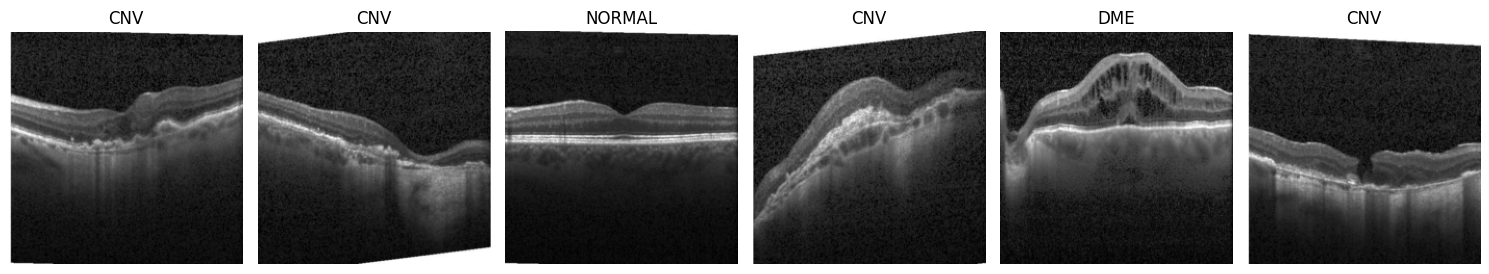

In [ ]:
# Show a few preprocessed training scans as a visual sanity check.
import matplotlib.pyplot as plt

g = torch.Generator().manual_seed(0)
idxs = torch.randperm(train_x.size(0), generator=g)[:6]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax, i in zip(axes, idxs):
    ax.imshow(train_x[i, 0], cmap="gray")
    ax.set_title(idx_to_class[train_y[i].item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Baseline — HOG + SVM

A classical, non-learning pipeline that sets the floor the CNN has to clear.

In [ ]:
# Baseline: Histogram of Oriented Gradients (HOG) features + an RBF-kernel SVM.
# HOG is a fixed, non-learned edge descriptor, so this measures how far a purely
# classical pipeline gets and gives the CNN a concrete target to beat.
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

PER_CLASS = 1500   # balanced subsample per class (SVMs scale poorly to 100k+ images)
HOG_SIZE  = 128    # images resized to 128x128 before extracting HOG features

In [ ]:
# Extract HOG features for a balanced subsample of the training set.
random.seed(42)
x, y = [], []

for class_name in classes:
    label  = class_to_idx[class_name]
    folder = os.path.join(ROOT, "train", class_name)
    chosen = random.sample(split_files["train"][class_name], PER_CLASS)

    for fname in chosen:
        img = Image.open(os.path.join(folder, fname)).convert("L").resize((HOG_SIZE, HOG_SIZE))
        features = hog(np.array(img), pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), orientations=9)
        x.append(features)
        y.append(label)

x = np.array(x)
y = np.array(y)
print("feature matrix shape:", x.shape)
print("labels shape:", y.shape)

feature matrix shape: (6000, 1764)
labels shape: (6000,)


In [ ]:
# Standardize features, then fit the RBF-kernel SVM.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

svm = SVC(kernel="rbf", C=10)
svm.fit(x_scaled, y)

SVC(C=10)

In [ ]:
# Extract HOG features for the full held-out test set (identical transform).
x_test, y_test = [], []

for class_name in classes:
    label  = class_to_idx[class_name]
    folder = os.path.join(ROOT, "test", class_name)
    for fname in os.listdir(folder):
        img = Image.open(os.path.join(folder, fname)).convert("L").resize((HOG_SIZE, HOG_SIZE))
        features = hog(np.array(img), pixels_per_cell=(16, 16),
                       cells_per_block=(2, 2), orientations=9)
        x_test.append(features)
        y_test.append(label)

x_test = np.array(x_test)
y_test = np.array(y_test)
x_test_scaled = scaler.transform(x_test)   # reuse the training scaler
print("test features:", x_test.shape)

test features: (1000, 1764)


In [ ]:
# Evaluate the baseline on the test set.
preds = svm.predict(x_test_scaled)

print("test accuracy:", round(accuracy_score(y_test, preds), 4))
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, target_names=classes))

test accuracy: 0.755
[[229  19   2   0]
 [ 30 214   2   4]
 [ 84  20 122  24]
 [  4  31  25 190]]
              precision    recall  f1-score   support

         CNV       0.66      0.92      0.77       250
         DME       0.75      0.86      0.80       250
      DRUSEN       0.81      0.49      0.61       250
      NORMAL       0.87      0.76      0.81       250

    accuracy                           0.76      1000
   macro avg       0.77      0.75      0.75      1000
weighted avg       0.77      0.76      0.75      1000



## 3. CNN model

In [ ]:
# Use the GPU if one is available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using:", device)

using: cuda


In [ ]:
# Three conv blocks (each: 3x3 conv -> ReLU -> 2x2 max-pool), channels 16 -> 32 -> 64,
# then a 128-unit dense layer to a 4-way output. ~6.45M parameters.
import torch.nn as nn
import torch.nn.functional as F

class OCT_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 28 * 28, 128)
        self.fc2   = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))   # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))   #  56 -> 28
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = OCT_CNN().to(device)
print(model)

OCT_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [ ]:
# Class-weighted loss to counter the heavy imbalance (Normal & CNV dominate).
# weight_c = total / (num_classes * count_c): rarer classes get up-weighted.
counts  = [(train_y == i).sum().item() for i in range(len(classes))]
weights = torch.tensor([sum(counts) / (len(classes) * n) for n in counts]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
print("class counts:", counts)
print("class weights:", weights)

class counts: [33932, 10227, 7863, 46028]
class weights: tensor([0.7224, 2.3968, 3.1174, 0.5326], device='cuda:0')


## 4. Training

In [ ]:
# Loss + accuracy over a loader (no gradients). uint8 images are scaled to [0, 1].
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device).float() / 255.0
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

In [ ]:
# Wrap the cached tensors in DataLoaders. num_workers=0 because the data already
# lives in RAM, there's nothing to prefetch from disk.
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(val_x,   val_y),   batch_size=128, shuffle=False, num_workers=0)
test_loader  = DataLoader(TensorDataset(test_x,  test_y),  batch_size=128, shuffle=False, num_workers=0)

print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 767
val batches:   81
test batches:  8


In [ ]:
# Fresh model + Adam optimizer for training.
model = OCT_CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training loop with early stopping on validation loss (patience 3).
# The best-by-val-loss weights are restored once training stops.
import copy

MAX_EPOCHS = 30
PATIENCE   = 3

best_val_loss     = float("inf")
best_model        = None
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images = images.to(device).float() / 255.0
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    val_loss, val_acc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"epoch {epoch+1}: train_loss {train_loss:.3f} train_acc {train_acc:.3f}"
          f" | val_loss {val_loss:.3f} val_acc {val_acc:.3f}")

    # Track the best weights; stop if val loss hasn't improved for PATIENCE epochs.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print("early stopping")
            break

model.load_state_dict(best_model)
print("done, best val_loss:", round(best_val_loss, 3))

epoch 1: train_loss 1.037 train_acc 0.594| val_loss 0.672 val_acc 0.749
epoch 2: train_loss 0.607 train_acc 0.803| val_loss 0.695 val_acc 0.727
epoch 3: train_loss 0.467 train_acc 0.848| val_loss 0.503 val_acc 0.816
epoch 4: train_loss 0.379 train_acc 0.876| val_loss 0.544 val_acc 0.812
epoch 5: train_loss 0.302 train_acc 0.899| val_loss 0.428 val_acc 0.852
epoch 6: train_loss 0.233 train_acc 0.920| val_loss 0.466 val_acc 0.851
epoch 7: train_loss 0.173 train_acc 0.940| val_loss 0.464 val_acc 0.850
epoch 8: train_loss 0.130 train_acc 0.953| val_loss 0.577 val_acc 0.834
early stopping
done, best val_loss: 0.428


In [ ]:
# Save the trained weights to Drive.
torch.save(model.state_dict(), WEIGHTS)
print("saved weights")

saved weights


In [ ]:
# Reload the trained weights (run this to evaluate without retraining).
model = OCT_CNN().to(device)
model.load_state_dict(torch.load(WEIGHTS, map_location=device))
model.eval()
print("loaded weights")

loaded weights


## 5. Evaluation

In [ ]:
# Test-set metrics: loss, accuracy, confusion matrix, and per-class report.
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_acc = evaluate(test_loader)
print(f"test loss {test_loss:.3f} | test acc {test_acc:.3f}\n")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device).float() / 255.0
        all_preds.append(model(images).argmax(1).cpu())
        all_labels.append(labels)
all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print("confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=classes))

test loss 0.427 | test acc 0.852

confusion matrix (rows=true, cols=pred):
[[237  11   1   1]
 [ 15 227   1   7]
 [ 54  11 162  23]
 [  2  12  10 226]]
              precision    recall  f1-score   support

         CNV       0.77      0.95      0.85       250
         DME       0.87      0.91      0.89       250
      DRUSEN       0.93      0.65      0.76       250
      NORMAL       0.88      0.90      0.89       250

    accuracy                           0.85      1000
   macro avg       0.86      0.85      0.85      1000
weighted avg       0.86      0.85      0.85      1000



## 6. Interpretability — Grad-CAM

Does the model look at clinically meaningful regions, or at spurious texture? Grad-CAM overlays show where each prediction comes from.

In [ ]:
# Grad-CAM: highlights the image regions that most influenced the predicted class.
# Forward/backward hooks capture the target conv layer's activations and gradients;
# the gradients are global-average-pooled into per-channel weights, combined with
# the activations, and ReLU'd into a coarse "where did the model look" heatmap.
import torch.nn.functional as F

def gradcam(img_uint8, target_layer):
    acts, grads = {}, {}
    h1 = target_layer.register_forward_hook(lambda m, i, o: acts.__setitem__("v", o.detach()))
    h2 = target_layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__("v", go[0].detach()))

    model.eval()
    x = img_uint8.unsqueeze(0).to(device).float() / 255.0
    out = model(x)
    pred = out.argmax(1).item()
    model.zero_grad()
    out[0, pred].backward()               # backprop the winning class score

    h1.remove(); h2.remove()

    a = acts["v"][0]                       # activations  [C, h, w]
    g = grads["v"][0]                      # gradients    [C, h, w]
    w = g.mean(dim=(1, 2))                 # channel weights = pooled gradients
    cam = F.relu((w[:, None, None] * a).sum(0))
    cam = cam / (cam.max() + 1e-8)         # normalize to [0, 1]
    cam = F.interpolate(cam[None, None], size=(224, 224), mode="bilinear", align_corners=False)[0, 0]
    return pred, cam.cpu().numpy()

In [ ]:
# Helper: run Grad-CAM on a list of test indices and show scan | heatmap per row.
# (Refactored out of the four near-identical plotting cells that follow.)
import matplotlib.pyplot as plt

def show_gradcam_grid(indices, true_titles=None):
    # indices     : test-set indices to visualize
    # true_titles : optional left-column titles (default: each scan's true class)
    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3 * len(indices)))
    if len(indices) == 1:
        axes = axes[None, :]
    for row, idx in enumerate(indices):
        img = test_x[idx, 0].numpy()
        pred, cam = gradcam(test_x[idx], model.conv3)   # last conv block
        left = true_titles[row] if true_titles else f"true: {classes[test_y[idx].item()]}"
        axes[row, 0].imshow(img, cmap="gray"); axes[row, 0].set_title(left); axes[row, 0].axis("off")
        axes[row, 1].imshow(img, cmap="gray")
        axes[row, 1].imshow(cam, cmap="jet", alpha=0.5)
        axes[row, 1].set_title(f"pred: {classes[pred]}"); axes[row, 1].axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
# Predict over the whole test set once, used to pick examples for the plots below.
model.eval()
preds_all = []
with torch.no_grad():
    for i in range(0, test_x.size(0), 128):
        xb = test_x[i:i+128].to(device).float() / 255.0
        preds_all.append(model(xb).argmax(1).cpu())
preds_all = torch.cat(preds_all)
correct = preds_all == test_y
print("test accuracy (recomputed):", correct.float().mean().item())

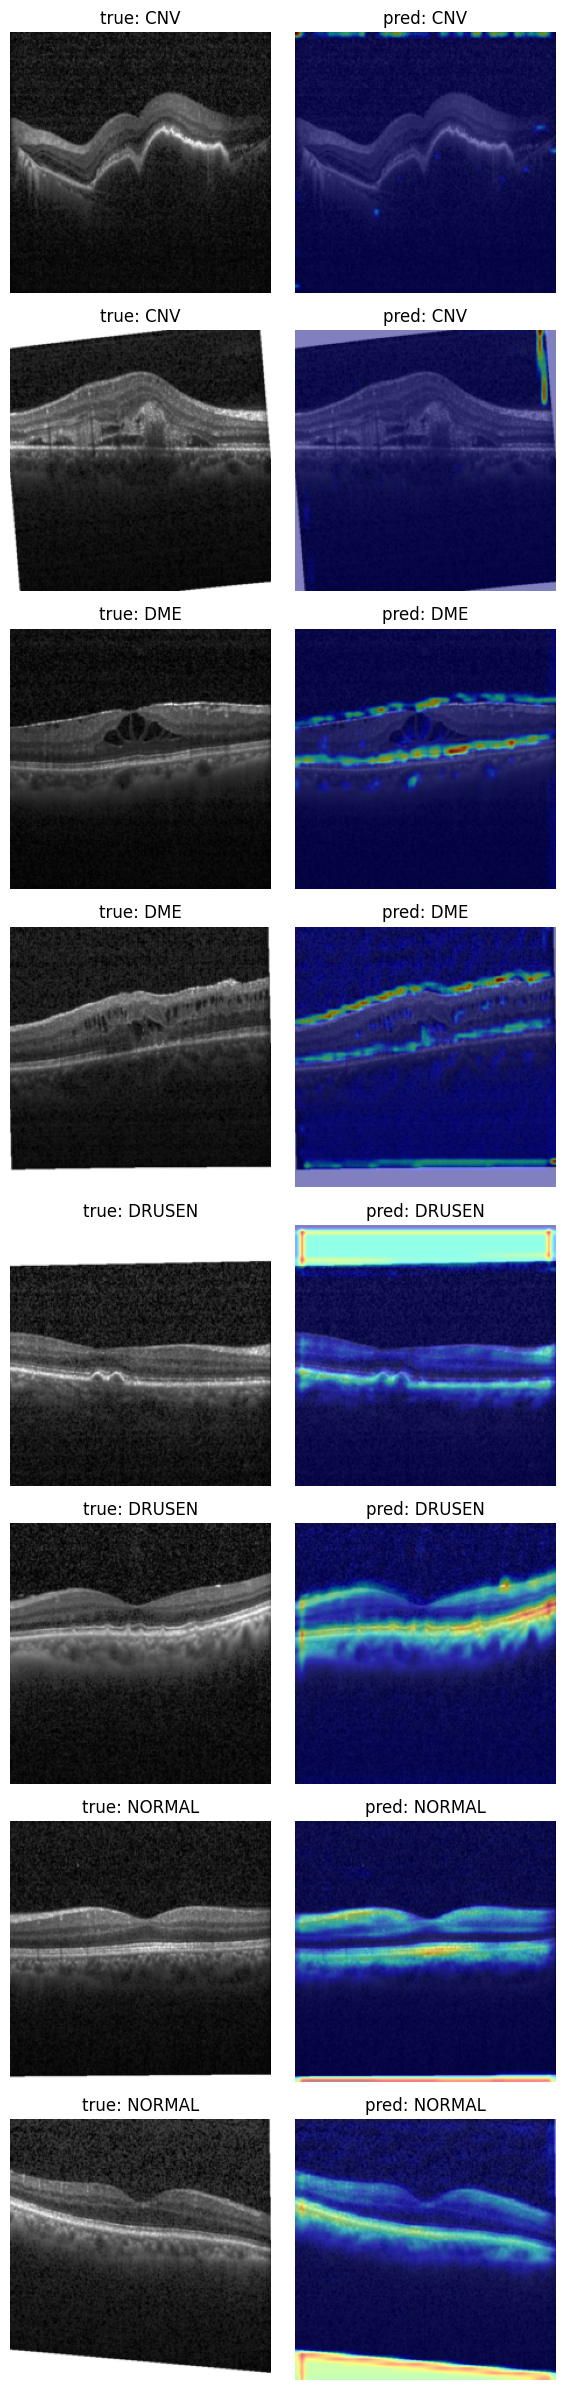

In [ ]:
# Grad-CAM on correctly classified examples: 2 per class.
chosen = []
for c in range(len(classes)):
    idxs = ((test_y == c) & correct).nonzero(as_tuple=True)[0]
    chosen += idxs[:2].tolist()
show_gradcam_grid(chosen)

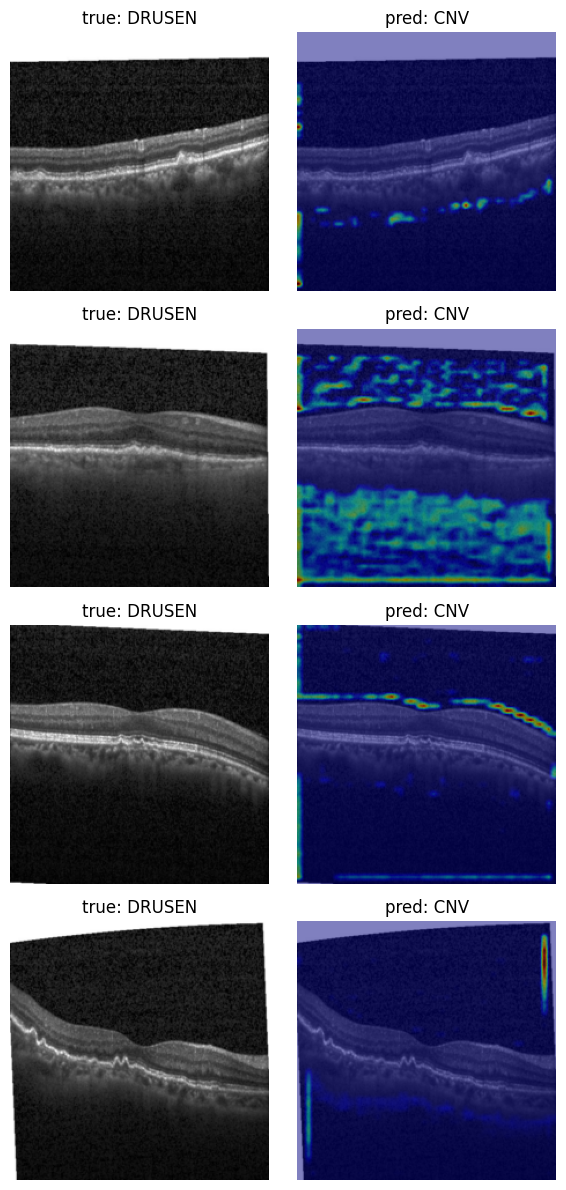

In [ ]:
# Grad-CAM on the model's most common error: drusen misclassified as CNV.
mask = (test_y == class_to_idx["DRUSEN"]) & (preds_all == class_to_idx["CNV"])
idxs = mask.nonzero(as_tuple=True)[0][:4].tolist()
show_gradcam_grid(idxs, true_titles=["true: DRUSEN"] * len(idxs))

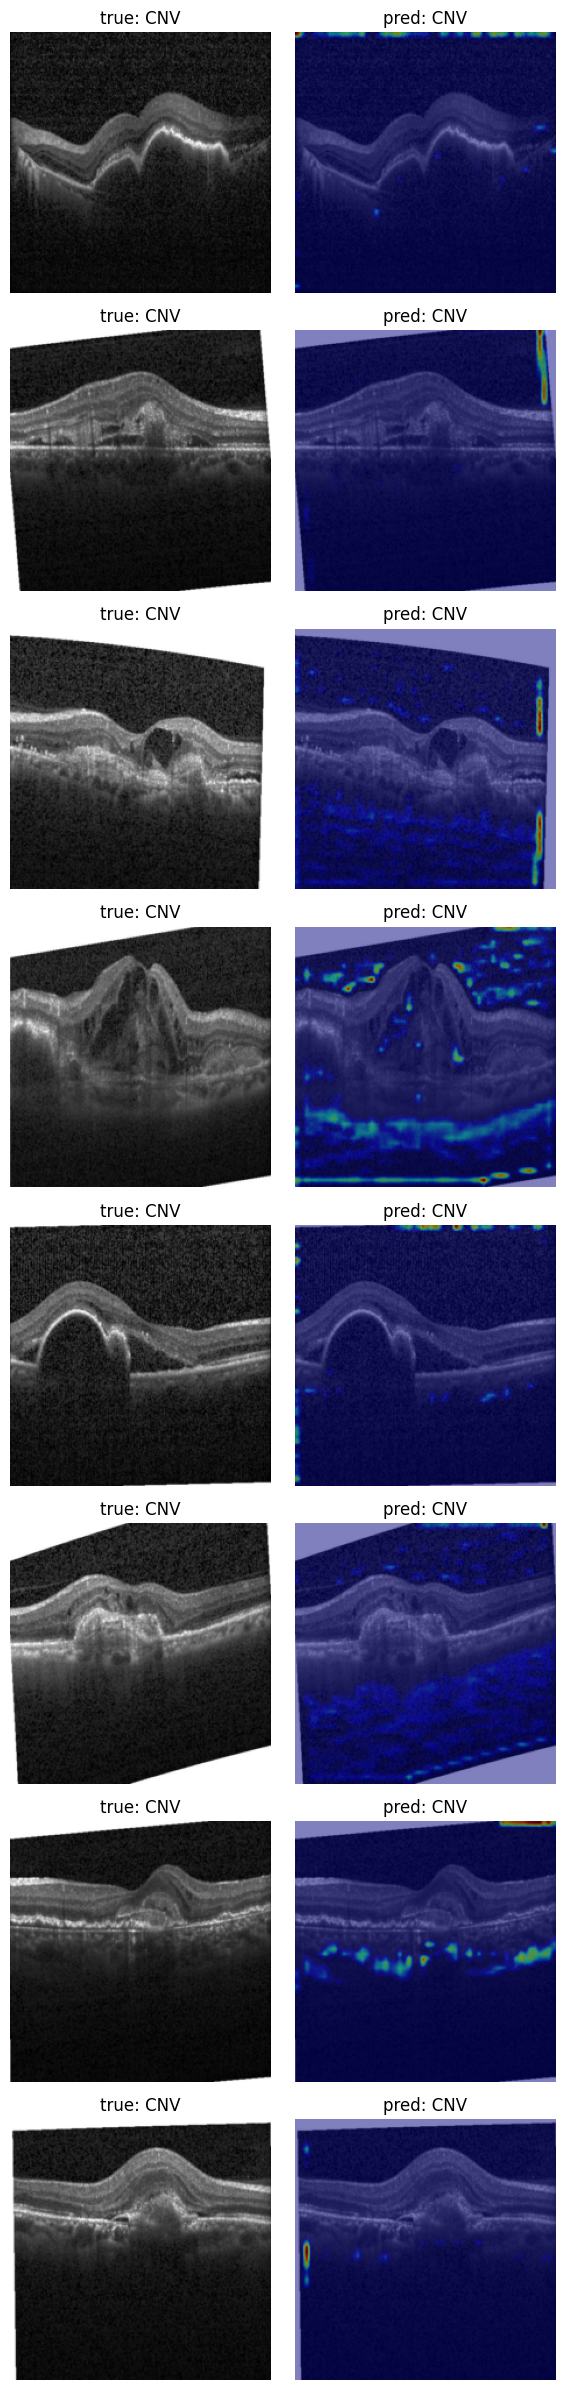

In [ ]:
# Grad-CAM on correctly classified CNV scans, note how inconsistent the attention is.
idxs = ((test_y == class_to_idx["CNV"]) & (preds_all == class_to_idx["CNV"])).nonzero(as_tuple=True)[0][:8].tolist()
show_gradcam_grid(idxs, true_titles=["true: CNV"] * len(idxs))

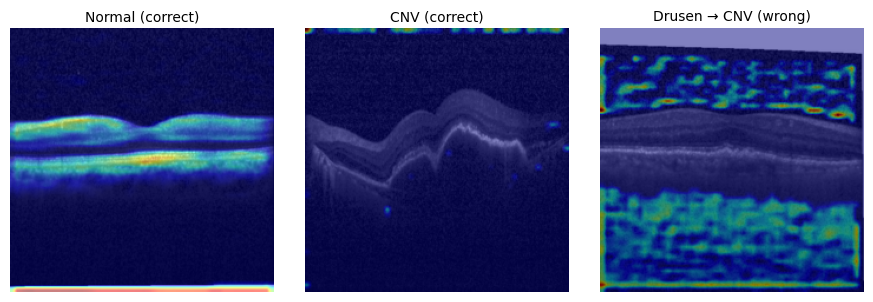

In [ ]:
# Summary figure: one clean example each of Normal (correct), CNV (correct),
# and a drusen scan misclassified as CNV.
def first(true_c, pred_c):
    m = (test_y == class_to_idx[true_c]) & (preds_all == class_to_idx[pred_c])
    return m.nonzero(as_tuple=True)[0][0].item()

cases = [
    ("Normal (correct)", first("NORMAL", "NORMAL")),
    ("CNV (correct)",    first("CNV", "CNV")),
    ("Drusen \u2192 CNV (wrong)", 511),   # a representative drusen->CNV error
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (title, idx) in zip(axes, cases):
    img = test_x[idx, 0].numpy()
    _, cam = gradcam(test_x[idx], model.conv3)
    ax.imshow(img, cmap="gray")
    ax.imshow(cam, cmap="jet", alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. External evaluation — OCTDL

Generalization to a different scanner and patient population the model never saw.

In [ ]:
# External test set: OCTDL, a different scanner and patient population, unseen in
# training. It labels drusen and neovascular cases jointly as AMD, so we later merge
# the model's CNV + drusen predictions into a single AMD class.
import os
from collections import Counter

folder_to_label = {"AMD": 0, "DME": 1, "NO": 2}   # "NO" = the Normal folder in OCTDL

octdl_items = []
for folder, label in folder_to_label.items():
    for fname in os.listdir(os.path.join(OCTDL_ROOT, folder)):
        octdl_items.append((os.path.join(OCTDL_ROOT, folder, fname), label))

print("evaluable images:", len(octdl_items))
print("label breakdown:", Counter(lbl for _, lbl in octdl_items))

evaluable images: 1710
label breakdown: Counter({0: 1231, 2: 332, 1: 147})


In [ ]:
# Decode OCTDL images with the exact same preprocessing used for training.
import time
from tqdm import tqdm

octdl_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.PILToTensor(),
])

octdl_x = torch.empty((len(octdl_items), 1, 224, 224), dtype=torch.uint8)
octdl_labels = torch.tensor([label for _, label in octdl_items])

t0 = time.time()
for i, (path, _) in enumerate(tqdm(octdl_items)):
    octdl_x[i] = octdl_transform(Image.open(path))
print(f"decoded {len(octdl_items)} in {time.time()-t0:.1f}s")

100%|██████████| 1710/1710 [00:15<00:00, 107.01it/s]

decoded 1710 in 16.0s
unique labels: [0, 1, 2]


In [ ]:
# Predict, then fold the 4-class output into OCTDL's 3-class scheme:
# CNV or DRUSEN -> AMD (0),  DME -> DME (1),  NORMAL -> Normal (2).
model.eval()
raw_preds = []
with torch.no_grad():
    for i in range(0, octdl_x.size(0), 128):
        xb = octdl_x[i:i+128].to(device).float() / 255.0
        raw_preds.append(model(xb).argmax(1).cpu())
raw_preds = torch.cat(raw_preds)

amd = {class_to_idx["CNV"], class_to_idx["DRUSEN"]}
octdl_preds = torch.tensor([0 if p.item() in amd else (1 if p.item() == class_to_idx["DME"] else 2)
                            for p in raw_preds])
print("unique predicted labels:", sorted(set(octdl_preds.tolist())))

unique predicted labels: [0, 1, 2]


In [ ]:
# OCTDL accuracy, confusion matrix, and per-class report.
from sklearn.metrics import confusion_matrix, classification_report

acc = (octdl_preds == octdl_labels).float().mean().item()
print(f"=== OCTDL 3-class {{AMD, DME, Normal}} — acc {acc:.3f} ===")
print(confusion_matrix(octdl_labels, octdl_preds))
print(classification_report(octdl_labels, octdl_preds, target_names=["AMD", "DME", "Normal"]))

=== OCTDL 3-class {AMD, DME, Normal} — acc 0.740 ===
[[1074  136   21]
 [  65   79    3]
 [  29  190  113]]
              precision    recall  f1-score   support

         AMD       0.92      0.87      0.90      1231
         DME       0.20      0.54      0.29       147
      Normal       0.82      0.34      0.48       332

    accuracy                           0.74      1710
   macro avg       0.65      0.58      0.55      1710
weighted avg       0.84      0.74      0.76      1710

